In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
import os
import pandas as pd


######### Load and quick check #########

In [2]:
train_path = "../data/cw1_train.csv"
test_path = "../data/cw1_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.head()

,outcome,carat,cut,color,clarity,depth,table,price,x,y,...,a6,a7,a8,a9,a10,b6,b7,b8,b9,b10
0,-26.701232,1.14,Ideal,G,VS1,62.3,56.0,7948,6.73,6.70,...,0.168836,-0.273758,1.107832,1.247795,0.482344,0.489511,-0.321138,0.573382,0.446871,-1.990581
1,6.548093,0.38,Premium,H,VS2,60.5,59.0,898,4.69,4.66,...,-0.256549,0.315373,-0.030326,-0.114335,-1.059588,-1.761360,-1.343951,-1.002550,-0.225030,-0.446653
2,6.612562,0.50,Very Good,E,SI1,60.7,58.0,1351,5.09,5.13,...,-1.193327,-0.657307,-0.591726,-0.446856,-0.765286,-0.816544,-1.397794,-0.477130,0.810509,1.725131
3,-5.073562,0.70,Premium,D,SI1,61.2,58.0,2512,5.74,5.70,...,-1.740788,-1.778860,-0.825070,0.444932,1.173109,0.453606,-0.263440,0.246210,-0.850503,-0.412950
4,-14.436557,0.83,Ideal,G,SI2,62.4,54.0,2751,6.01,6.08,...,-0.859322,1.409268,0.861992,1.109063,-1.436722,-1.461618,0.081787,0.258087,0.851146,2.204813


In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.columns

Train shape: (10000, 31)
Test shape: (1000, 30)


Index(['outcome', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z', 'a1', 'a2', 'a3', 'a4', 'a5', 'b1', 'b2', 'b3',
       'b4', 'b5', 'a6', 'a7', 'a8', 'a9', 'a10', 'b6', 'b7', 'b8', 'b9',
       'b10'],
      dtype='str')

######### EDA: data quality and types #########

In [4]:
missing = train_df.isna().sum().sort_values(ascending=False)
missing.head(10)

outcome    0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
dtype: int64

In [5]:
train_df.dtypes

outcome    float64
carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
a1         float64
a2         float64
a3         float64
a4         float64
a5         float64
b1         float64
b2         float64
b3         float64
b4         float64
b5         float64
a6         float64
a7         float64
a8         float64
a9         float64
a10        float64
b6         float64
b7         float64
b8         float64
b9         float64
b10        float64
dtype: object

In [6]:
train_df.duplicated().sum()

np.int64(0)

########## EDA: target distribution ############

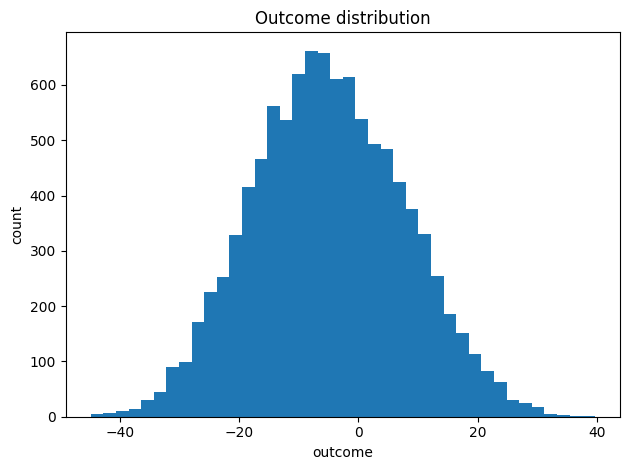

In [7]:
plt.figure()
plt.hist(train_df["outcome"], bins=40)
plt.title("Outcome distribution")
plt.xlabel("outcome")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("../outcome_hist.png", dpi=200)
plt.show()

In [8]:
y = train_df["outcome"]
X = train_df.drop(columns=["outcome"])

X.shape, y.shape

((10000, 30), (10000,))

EDA: categorical distributions

In [9]:
for col in ["cut", "color", "clarity"]:
    print("\n", col)
    print(train_df[col].value_counts())


 cut
cut
Ideal        4040
Premium      2439
Very Good    2296
Good          925
Fair          300
Name: count, dtype: int64

 color
color
G    2120
E    1873
F    1746
H    1506
D    1246
I     983
J     526
Name: count, dtype: int64

 clarity
clarity
SI1     2408
VS2     2256
SI2     1743
VS1     1503
VVS2     951
VVS1     675
IF       318
I1       146
Name: count, dtype: int64


EDA: numeric summaries and checks

In [10]:
train_df.describe().T[["mean","std","min","max"]].head(10)


,mean,std,min,max
outcome,-4.979081,12.722224,-44.879471,39.675966
carat,0.798407,0.472046,0.200000,4.000000
depth,61.748060,1.429631,50.800000,70.500000
table,57.467360,2.247036,44.000000,73.000000
price,3910.841900,3940.369616,326.000000,18791.000000
x,5.733974,1.114850,0.000000,10.010000
y,5.741665,1.228057,0.000000,58.900000
z,3.540757,0.692502,0.000000,8.060000
a1,0.502349,0.291012,0.000128,0.999789
a2,0.507509,0.291207,0.000101,0.999976


In [11]:
train_df[["x","y","z"]].describe()


,x,y,z
count,10000.000000,10000.000000,10000.000000
mean,5.733974,5.741665,3.540757
std,1.114850,1.228057,0.692502
min,0.000000,0.000000,0.000000
25%,4.730000,4.740000,2.920000
50%,5.700000,5.720000,3.530000
75%,6.530000,6.530000,4.030000
max,10.010000,58.900000,8.060000


In [12]:
(train_df[["x","y","z"]] == 0).sum()

x    2
y    2
z    4
dtype: int64

#####DATA PROCESSING: remove invalid physical rows (x/y/z == 0)

In [13]:
train_df = train_df[(train_df["x"] > 0) &
                    (train_df["y"] > 0) &
                    (train_df["z"] > 0)]

train_df.shape

(9996, 31)

Create X and y (after cleaning)

In [14]:
y = train_df["outcome"]
X = train_df.drop(columns=["outcome"])

X.shape, y.shape

((9996, 30), (9996,))

Define numeric vs categorical features (for preprocessing)

In [15]:
categorical_features = ["cut", "color", "clarity"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Categorical:", categorical_features)
print("Num features", len(numeric_features))

Categorical: ['cut', 'color', 'clarity']
Num features 27


EDA: numeric scale/outliers visualization

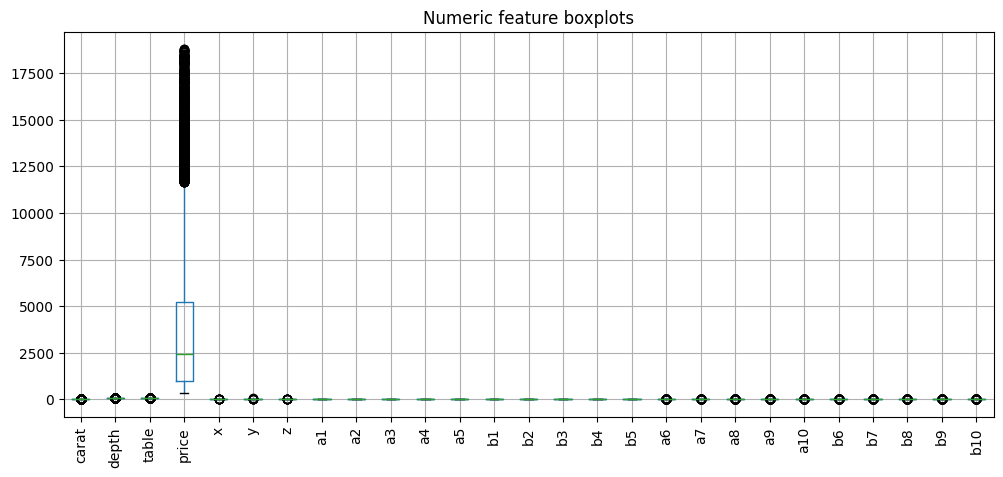

In [16]:
#select only numeric features
numeric_df = train_df[numeric_features]

plt.figure(figsize=(12,5))
numeric_df.boxplot(rot=90)
plt.title("Numeric feature boxplots")
plt.show()

EDA: correlation

In [17]:
num_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[num_cols].corr()["outcome"].sort_values(key=lambda s: s.abs(), ascending=False)
corr.head(10)


outcome    1.000000
depth     -0.410888
b3         0.225374
b1         0.173464
a1         0.149210
a4         0.122474
table      0.114946
z         -0.029914
x          0.020477
price      0.016670
Name: outcome, dtype: float64

EDA: simple relationships

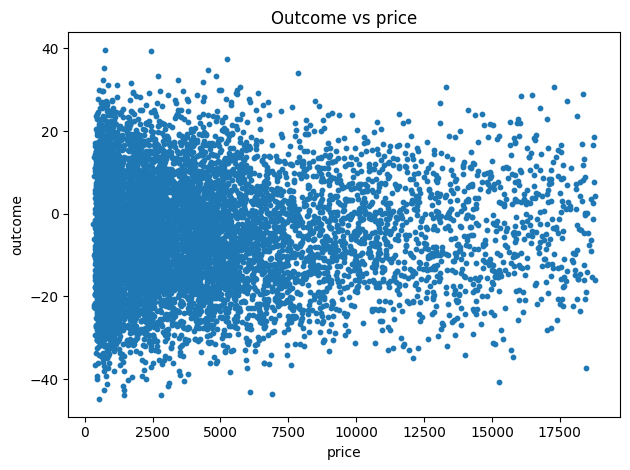

In [18]:
plt.figure()
plt.scatter(train_df["price"], train_df["outcome"], s=10)
plt.xlabel("price")
plt.ylabel("outcome")
plt.title("Outcome vs price")
plt.tight_layout()
plt.savefig("../outcome_vs_price.png", dpi=200)
plt.show()


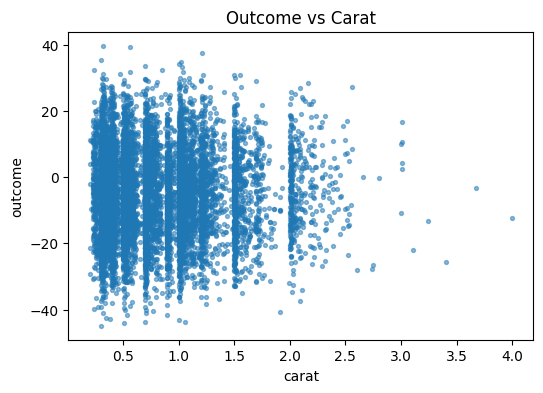

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(train_df["carat"], train_df["outcome"], s=8, alpha=0.5)
plt.xlabel("carat")
plt.ylabel("outcome")
plt.title("Outcome vs Carat")
plt.show()


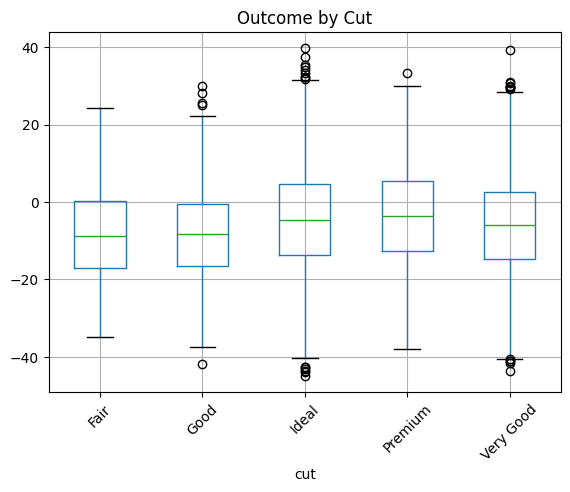

In [20]:
train_df.boxplot(column="outcome", by="cut", rot=45)
plt.title("Outcome by Cut")
plt.suptitle("")
plt.show()

Outlier counts

In [21]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < low) | (s > high)).sum()

for col in ["price", "carat", "x", "y", "z"]:
    print(col, iqr_outlier_count(train_df[col]))


price 675
carat 332
x 8
y 7
z 8


IQR analysis indicated a large number of statistical outliers in price and carat, reflecting natural variability rather than measurement error. Only physically impossible values (zero dimensions) were removed.

**DATA PROCESSING**

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_val.shape


((7996, 30), (2000, 30))

In [23]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [24]:
ridge_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge())
])

ridge_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [25]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(ridge_model, X, y, scoring="r2", cv=cv, n_jobs=-1)
scores.mean(), scores.std()

(np.float64(0.2864679701055557), np.float64(0.009000760499045284))

Model Comparison

In [26]:
models = {
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "HistGB": HistGradientBoostingRegressor(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X, y, scoring="r2", cv=cv, n_jobs=-1)
    print(f"{name}: mean R2 = {scores.mean():.4f}  std = {scores.std():.4f}")


Ridge: mean R2 = 0.2865  std = 0.0090
RandomForest: mean R2 = 0.4539  std = 0.0170
HistGB: mean R2 = 0.4582  std = 0.0158


Hyperparameter Search

In [27]:
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

param_dist = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, None],
    "model__max_leaf_nodes": [31, 63, 127],
    "model__l2_regularization": [0.0, 0.1, 1.0],
    "model__min_samples_leaf": [10, 20, 30]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y)

print("Best CV R2:", search.best_score_)
print("Best params:", search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV R2: 0.4740974231104914
Best params: {'model__min_samples_leaf': 30, 'model__max_leaf_nodes': 127, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__l2_regularization': 1.0}


Define final model

In [28]:
final_model = search.best_estimator_

final_model

final_model.fit(X, y)

test_preds = final_model.predict(test_df)

test_preds[:10]




array([  3.18856823,  -7.07956322,   5.84379124, -17.89649316,
       -15.12828854, -13.18698372,   1.6561711 ,  -8.15248422,
         5.14317041,   3.87068216])

In [29]:
os.makedirs("../outputs", exist_ok=True)

submission_path = "../outputs/CW1_submission_K24066802.csv" 

pd.DataFrame({"yhat": test_preds}).to_csv(submission_path, index=False)

pd.read_csv(submission_path).head()


,yhat
0,3.188568
1,-7.079563
2,5.843791
3,-17.896493
4,-15.128289
